# NetGuard Cognitive Cybersecurity Prototype

**Practical Assignment 3 — Implementation of a Cognitive Prototype of an AI System**

NetGuard is a cybersecurity AI prototype that classifies network connections as **Normal** or **Anomaly**.

The previous research stage compared four alternative AI approaches: Random Forest, FT-Transformer, GCN, and TabPFN. For this cognitive prototype, **Random Forest** is used as the operational inference engine because it is already trained, provides strong performance, supports `predict_proba`, and exposes feature importance for an interpretable Attention module.

**Integrated cognitive pipeline:**

**Input → Perception → Attention → Memory → Knowledge Representation → Output**

In [1]:
import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from pathlib import Path
from collections import deque
from datetime import datetime, timezone
from IPython.display import display

print("Python executable:", sys.executable)
print("Python version:", sys.version)

Python executable: c:\Users\user\Desktop\NetGuard\.venv\Scripts\python.exe
Python version: 3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]


In [2]:
# Automatically locate the NetGuard repository root.
current_path = Path.cwd().resolve()
PROJECT_ROOT = None

for candidate in [current_path, *current_path.parents]:
    if ((candidate / "data" / "KDDTrain+.txt").exists()
        and (candidate / "results" / "models").exists()):
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("NetGuard project root was not found.")

DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "results" / "models"
MEMORY_DIR = PROJECT_ROOT / "memory"
MEMORY_DIR.mkdir(exist_ok=True)

TRAIN_PATH = DATA_DIR / "KDDTrain+.txt"
TEST_PATH = DATA_DIR / "KDDTest+.txt"
RF_MODEL_PATH = MODEL_DIR / "random_forest.pkl"
SCALER_PATH = MODEL_DIR / "scaler.pkl"
ENCODERS_PATH = MODEL_DIR / "label_encoders.pkl"
MEMORY_PATH = MEMORY_DIR / "assignment3_netguard_memory.json"

print("Project root:", PROJECT_ROOT)
print("Training data:", TRAIN_PATH)
print("Test data:", TEST_PATH)
print("Long-term memory:", MEMORY_PATH)

Project root: C:\Users\user\Desktop\NetGuard
Training data: C:\Users\user\Desktop\NetGuard\data\KDDTrain+.txt
Test data: C:\Users\user\Desktop\NetGuard\data\KDDTest+.txt
Long-term memory: C:\Users\user\Desktop\NetGuard\memory\assignment3_netguard_memory.json


## Cognitive Architecture

```text
Raw Network Record
        ↓
   PERCEPTION
Encoding + Scaling
        ↓
    ATTENTION
Feature Importance
        ↓
 AI CLASSIFIER
 Random Forest
        ↓
      MEMORY
Short-Term + Long-Term
        ↓
KNOWLEDGE REPRESENTATION
Entities + Relations + Rules
        ↓
      OUTPUT
Prediction + Risk + Explanation
```

In [3]:
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files",
    "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label", "difficulty"
]

train_df = pd.read_csv(TRAIN_PATH, names=columns)
test_df = pd.read_csv(TEST_PATH, names=columns)

train_df["binary_label"] = (train_df["label"] != "normal").astype(int)
test_df["binary_label"] = (test_df["label"] != "normal").astype(int)

categorical_cols = ["protocol_type", "service", "flag"]
feature_cols = [c for c in columns if c not in ["label", "difficulty"]]
numerical_cols = [c for c in feature_cols if c not in categorical_cols]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Model features:", len(feature_cols))
print("Categorical features:", len(categorical_cols))
print("Numerical features:", len(numerical_cols))

Train shape: (125973, 44)
Test shape: (22544, 44)
Model features: 41
Categorical features: 3
Numerical features: 38


In [4]:
print("Training class distribution:")
display(train_df["binary_label"].value_counts().rename(index={0:"Normal",1:"Anomaly"}).to_frame("count"))

print("\nExample raw records:")
display(train_df[["protocol_type","service","flag","src_bytes","dst_bytes","count","srv_count","label","binary_label"]].head())

Training class distribution:


,count
binary_label,
Normal,67343
Anomaly,58630



Example raw records:


,protocol_type,service,flag,src_bytes,dst_bytes,count,srv_count,label,binary_label
0,tcp,ftp_data,SF,491,0,2,2,normal,0
1,udp,other,SF,146,0,13,1,normal,0
2,tcp,private,S0,0,0,123,6,neptune,1
3,tcp,http,SF,232,8153,5,5,normal,0
4,tcp,http,SF,199,420,30,32,normal,0


# Module 1 — Perception

The Perception module converts a raw NSL-KDD connection into the numerical representation expected by the trained model.

- 3 categorical features: `protocol_type`, `service`, `flag`
- 38 numerical features
- categorical values are encoded by saved `LabelEncoder` objects
- numerical values are standardized by the saved `StandardScaler`
- output: a **41-dimensional numerical vector**

In [5]:
label_encoders = joblib.load(ENCODERS_PATH)
scaler = joblib.load(SCALER_PATH)
rf_model = joblib.load(RF_MODEL_PATH)

print("Loaded encoders:", list(label_encoders.keys()))
print("Random Forest classes:", rf_model.classes_)
print("Expected features:", rf_model.n_features_in_)

assert rf_model.n_features_in_ == len(feature_cols)
assert hasattr(rf_model, "feature_importances_")

Loaded encoders: ['protocol_type', 'service', 'flag']
Random Forest classes: [0 1]
Expected features: 41


In [6]:
def perception(raw_record):
    if isinstance(raw_record, pd.Series):
        raw_record = raw_record.to_dict()

    frame = pd.DataFrame([{col: raw_record[col] for col in feature_cols}])

    for col in categorical_cols:
        encoder = label_encoders[col]
        value = str(frame.at[0, col])
        if value not in encoder.classes_:
            raise ValueError(f"Unknown category '{value}' in '{col}'")
        frame[col] = encoder.transform([value])

    frame[numerical_cols] = scaler.transform(frame[numerical_cols])
    return frame.astype(np.float32)


def perception_batch(raw_dataframe):
    frame = raw_dataframe[feature_cols].copy()
    for col in categorical_cols:
        encoder = label_encoders[col]
        frame[col] = encoder.transform(frame[col].astype(str))
    frame[numerical_cols] = scaler.transform(frame[numerical_cols])
    return frame.astype(np.float32)

In [7]:
sample_raw = test_df.iloc[0]
print("RAW INPUT:")
display(sample_raw[["protocol_type","service","flag","src_bytes","dst_bytes","count","srv_count","label"]].to_frame("value"))

sample_perceived = perception(sample_raw)
print("\nPERCEPTION OUTPUT:")
print("Shape:", sample_perceived.shape)
display(sample_perceived.iloc[:, :12].T.rename(columns={0:"processed_value"}))

RAW INPUT:


,value
protocol_type,tcp
service,private
flag,REJ
src_bytes,0
dst_bytes,0
count,229
srv_count,10
label,neptune



PERCEPTION OUTPUT:
Shape: (1, 41)


,processed_value
duration,-0.112481
protocol_type,1.000000
service,49.000000
flag,1.000000
src_bytes,-0.007436
dst_bytes,-0.004614
land,-0.014680
wrong_fragment,-0.085488
urgent,-0.010403
hot,-0.094071


# Module 2 — Attention / Selection

The prototype uses **Random Forest feature importance** as an interpretable attention criterion.

Higher feature importance means greater relevance to the anomaly-classification task. The module ranks all 41 features and compares high-relevance versus low-relevance inputs.

In [8]:
attention_table = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

attention_table["rank"] = np.arange(1, len(attention_table)+1)
attention_table = attention_table[["rank","feature","importance"]]
display(attention_table.head(15))

,rank,feature,importance
0,1,src_bytes,0.172345
1,2,dst_bytes,0.116215
2,3,flag,0.080317
3,4,same_srv_rate,0.071144
4,5,dst_host_srv_count,0.068655
5,6,dst_host_same_srv_rate,0.064480
6,7,logged_in,0.046040
7,8,diff_srv_rate,0.042723
8,9,dst_host_diff_srv_rate,0.039633
9,10,protocol_type,0.036045


In [9]:
high_relevance = attention_table.head(5).copy()
high_relevance["relevance_group"] = "HIGH"
low_relevance = attention_table.tail(5).copy()
low_relevance["relevance_group"] = "LOW"

attention_comparison = pd.concat([high_relevance, low_relevance], ignore_index=True)
print("High vs low relevance:")
display(attention_comparison)

High vs low relevance:


,rank,feature,importance,relevance_group
0,1,src_bytes,0.172345,HIGH
1,2,dst_bytes,0.116215,HIGH
2,3,flag,0.080317,HIGH
3,4,same_srv_rate,0.071144,HIGH
4,5,dst_host_srv_count,0.068655,HIGH
5,37,urgent,0.000041,LOW
6,38,su_attempted,0.000033,LOW
7,39,land,0.000022,LOW
8,40,num_outbound_cmds,0.000000,LOW
9,41,is_host_login,0.000000,LOW


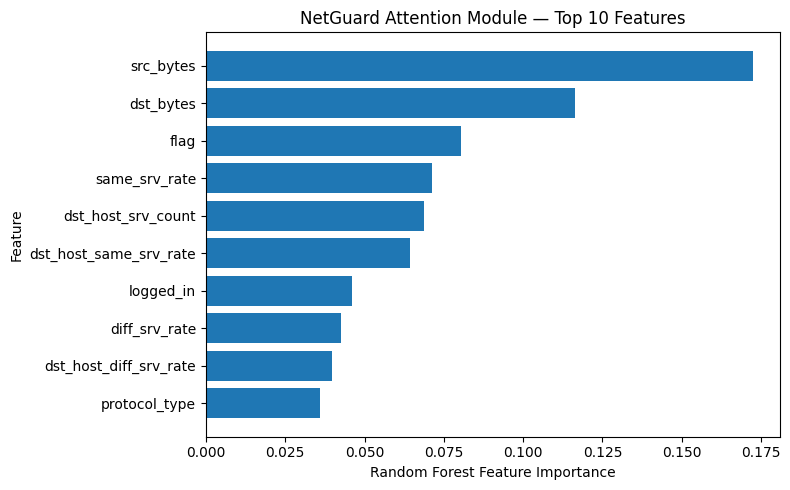

In [10]:
top_attention = attention_table.head(10).sort_values("importance")
plt.figure(figsize=(8,5))
plt.barh(top_attention["feature"], top_attention["importance"])
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.title("NetGuard Attention Module — Top 10 Features")
plt.tight_layout()
plt.show()

In [11]:
def attention_for_record(raw_record, processed_record, top_n=5):
    selected = attention_table.head(top_n)["feature"].tolist()
    rows=[]
    for feature in selected:
        rows.append({
            "feature": feature,
            "importance": float(attention_table.loc[attention_table["feature"]==feature,"importance"].iloc[0]),
            "raw_value": raw_record[feature],
            "processed_value": float(processed_record.iloc[0][feature])
        })
    return pd.DataFrame(rows)

sample_attention = attention_for_record(sample_raw, sample_perceived)
display(sample_attention)

,feature,importance,raw_value,processed_value
0,src_bytes,0.172345,0,-0.007436
1,dst_bytes,0.116215,0,-0.004614
2,flag,0.080317,REJ,1.000000
3,same_srv_rate,0.071144,0.04,-1.449992
4,dst_host_srv_count,0.068655,10,-0.984094


# AI Decision Engine

For Assignment 3, Random Forest is used as the operational classifier. The four models from the research stage remain alternative AI engines; they are not a four-model ensemble.

Decision threshold used in the current prototype:

- probability < 0.50 → **Normal**
- probability ≥ 0.50 → **Anomaly**

In [12]:
rf_classes = list(rf_model.classes_)
if 1 not in rf_classes:
    raise ValueError("Anomaly class 1 is missing")
ANOMALY_COLUMN = rf_classes.index(1)

def predict_anomaly(processed_record):
    probability = float(rf_model.predict_proba(processed_record)[0, ANOMALY_COLUMN])
    prediction = int(probability >= 0.50)
    return {
        "probability": probability,
        "prediction": prediction,
        "prediction_name": "Anomaly" if prediction else "Normal"
    }

sample_prediction = predict_anomaly(sample_perceived)
sample_prediction

c:\Users\user\Desktop\NetGuard\.venv\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


{'probability': 1.0, 'prediction': 1, 'prediction_name': 'Anomaly'}

In [13]:
X_test_processed = perception_batch(test_df)
test_probabilities = rf_model.predict_proba(X_test_processed)[:, ANOMALY_COLUMN]
test_predictions = (test_probabilities >= 0.50).astype(int)

evaluation_df = test_df[["protocol_type","service","flag","label","binary_label"]].copy()
evaluation_df["anomaly_probability"] = test_probabilities
evaluation_df["prediction"] = test_predictions
evaluation_df["prediction_name"] = np.where(test_predictions==1, "Anomaly", "Normal")

print("Test records evaluated:", len(evaluation_df))
display(evaluation_df.head())

Test records evaluated: 22544


c:\Users\user\Desktop\NetGuard\.venv\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


,protocol_type,service,flag,label,binary_label,anomaly_probability,prediction,prediction_name
0,tcp,private,REJ,neptune,1,1.000000,1,Anomaly
1,tcp,private,REJ,neptune,1,1.000000,1,Anomaly
2,tcp,ftp_data,SF,normal,0,0.000000,0,Normal
3,icmp,eco_i,SF,saint,1,0.916824,1,Anomaly
4,tcp,telnet,RSTO,mscan,1,0.300000,0,Normal


# Module 3 — Memory

## Short-Term Memory
Uses a Python `deque` to keep the most recent events from the current session.

## Long-Term Memory
Uses `memory/assignment3_netguard_memory.json` to persist events across program runs.

The module supports:

- write operation
- retrieval operation
- search for previous similar anomalies

Long-term memory is later used to influence the risk decision.

In [14]:
class ShortTermMemory:
    def __init__(self, max_events=5):
        self.events = deque(maxlen=max_events)
    def remember(self, event):
        self.events.append(event)
    def retrieve_recent(self):
        return list(self.events)
    def clear(self):
        self.events.clear()

short_term_memory = ShortTermMemory(max_events=5)
print("Short-term memory initialized.")

Short-term memory initialized.


In [15]:
class LongTermMemory:
    def __init__(self, path):
        self.path = Path(path)
        self.path.parent.mkdir(parents=True, exist_ok=True)
        if not self.path.exists():
            self._save([])

    def _load(self):
        try:
            with open(self.path, "r", encoding="utf-8") as f:
                data = json.load(f)
            return data if isinstance(data, list) else []
        except (json.JSONDecodeError, FileNotFoundError):
            return []

    def _save(self, data):
        with open(self.path, "w", encoding="utf-8") as f:
            json.dump(data, f, indent=2, ensure_ascii=False)

    def write_event(self, event):
        data = self._load()
        event_id = event["event_id"]
        data = [x for x in data if x.get("event_id") != event_id]
        data.append(event)
        self._save(data)

    def retrieve_all(self):
        return self._load()

    def retrieve_recent(self, n=5):
        return self._load()[-n:]

    def find_similar_anomalies(self, protocol_type, service, exclude_event_id=None):
        matches=[]
        for event in self._load():
            if exclude_event_id is not None and event.get("event_id") == exclude_event_id:
                continue
            if (event.get("protocol_type") == protocol_type
                and event.get("service") == service
                and event.get("prediction") == "Anomaly"):
                matches.append(event)
        return matches

long_term_memory = LongTermMemory(MEMORY_PATH)
print("Long-term memory initialized:", MEMORY_PATH)
print("Stored events:", len(long_term_memory.retrieve_all()))

Long-term memory initialized: C:\Users\user\Desktop\NetGuard\memory\assignment3_netguard_memory.json
Stored events: 0


In [ ]:
# OPTIONAL RESET CELL
# Uncomment only when you want to clear persistent demo memory.

# if MEMORY_PATH.exists():
#     MEMORY_PATH.unlink()
# long_term_memory = LongTermMemory(MEMORY_PATH)
# short_term_memory.clear()
# print("Demo memory cleared.")

# Module 4 — Knowledge Representation

NetGuard uses a hybrid representation of cybersecurity knowledge:

### Entities
- `NetworkConnection`
- `Protocol`
- `Service`
- `Prediction`
- `RiskLevel`
- `SecurityAction`

### Relationships
- NetworkConnection **uses** Protocol
- NetworkConnection **accesses** Service
- NetworkConnection **produces** Prediction
- Prediction **has** RiskLevel
- RiskLevel **triggers** SecurityAction

### Rules
- **K1:** IF probability ≥ 0.80 THEN risk = HIGH
- **K2:** IF 0.50 ≤ probability < 0.80 THEN risk = MEDIUM
- **K3:** IF probability < 0.50 THEN risk = LOW
- **K4:** IF current event is Anomaly AND at least 2 previous similar anomalies exist THEN increase risk priority

The 0.50/0.80 policy is a prototype rule set, not a production-calibrated security policy.

In [16]:
knowledge_base = {
    "entities": ["NetworkConnection","Protocol","Service","Prediction","RiskLevel","SecurityAction"],
    "relationships": [
        ("NetworkConnection","uses","Protocol"),
        ("NetworkConnection","accesses","Service"),
        ("NetworkConnection","produces","Prediction"),
        ("Prediction","has","RiskLevel"),
        ("RiskLevel","triggers","SecurityAction")
    ],
    "rules": {
        "K1": "IF probability >= 0.80 THEN risk = HIGH",
        "K2": "IF 0.50 <= probability < 0.80 THEN risk = MEDIUM",
        "K3": "IF probability < 0.50 THEN risk = LOW",
        "K4": "IF prediction = Anomaly AND previous similar anomalies >= 2 THEN increase risk priority"
    }
}

print("Entities:")
display(pd.DataFrame({"entity": knowledge_base["entities"]}))
print("\nRelationships:")
display(pd.DataFrame(knowledge_base["relationships"], columns=["source","relationship","target"]))
print("\nRules:")
display(pd.DataFrame(list(knowledge_base["rules"].items()), columns=["rule","definition"]))

Entities:


,entity
0,NetworkConnection
1,Protocol
2,Service
3,Prediction
4,RiskLevel
5,SecurityAction



Relationships:


,source,relationship,target
0,NetworkConnection,uses,Protocol
1,NetworkConnection,accesses,Service
2,NetworkConnection,produces,Prediction
3,Prediction,has,RiskLevel
4,RiskLevel,triggers,SecurityAction



Rules:


,rule,definition
0,K1,IF probability >= 0.80 THEN risk = HIGH
1,K2,IF 0.50 <= probability < 0.80 THEN risk = MEDIUM
2,K3,IF probability < 0.50 THEN risk = LOW
3,K4,IF prediction = Anomaly AND previous similar a...


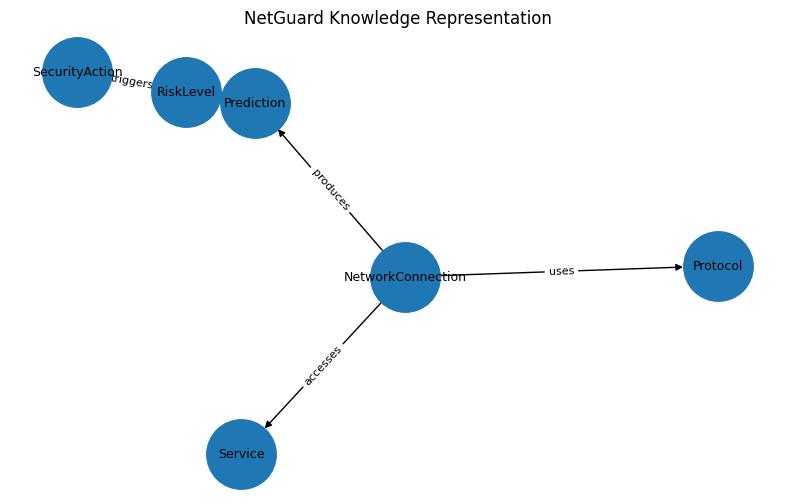

In [17]:
knowledge_graph = nx.DiGraph()
for entity in knowledge_base["entities"]:
    knowledge_graph.add_node(entity)
for source, relation, target in knowledge_base["relationships"]:
    knowledge_graph.add_edge(source, target, relation=relation)

plt.figure(figsize=(10,6))
pos = nx.spring_layout(knowledge_graph, seed=42)
nx.draw_networkx(knowledge_graph, pos=pos, with_labels=True, node_size=2500, font_size=9, arrows=True)
edge_labels = nx.get_edge_attributes(knowledge_graph, "relation")
nx.draw_networkx_edge_labels(knowledge_graph, pos=pos, edge_labels=edge_labels, font_size=8)
plt.title("NetGuard Knowledge Representation")
plt.axis("off")
plt.show()

In [18]:
def knowledge_inference(anomaly_probability, previous_similar_anomalies):
    fired_rules=[]

    if anomaly_probability >= 0.80:
        base_risk="HIGH"
        recommendation="Immediate analyst review"
        fired_rules.append("K1")
    elif anomaly_probability >= 0.50:
        base_risk="MEDIUM"
        recommendation="Inspect suspicious connection"
        fired_rules.append("K2")
    else:
        base_risk="LOW"
        recommendation="Continue monitoring"
        fired_rules.append("K3")

    final_risk=base_risk

    if anomaly_probability >= 0.50 and previous_similar_anomalies >= 2:
        fired_rules.append("K4")
        if base_risk == "MEDIUM":
            final_risk="HIGH"
        elif base_risk == "HIGH":
            final_risk="CRITICAL"
        recommendation="Escalate to analyst: repeated anomalous protocol/service pattern found in long-term memory"

    return {
        "base_risk": base_risk,
        "final_risk": final_risk,
        "recommendation": recommendation,
        "fired_rules": fired_rules
    }

for p, previous in [(0.20,0),(0.65,0),(0.91,0),(0.65,3)]:
    print(p, previous, "->", knowledge_inference(p, previous))

0.2 0 -> {'base_risk': 'LOW', 'final_risk': 'LOW', 'recommendation': 'Continue monitoring', 'fired_rules': ['K3']}
0.65 0 -> {'base_risk': 'MEDIUM', 'final_risk': 'MEDIUM', 'recommendation': 'Inspect suspicious connection', 'fired_rules': ['K2']}
0.91 0 -> {'base_risk': 'HIGH', 'final_risk': 'HIGH', 'recommendation': 'Immediate analyst review', 'fired_rules': ['K1']}
0.65 3 -> {'base_risk': 'MEDIUM', 'final_risk': 'HIGH', 'recommendation': 'Escalate to analyst: repeated anomalous protocol/service pattern found in long-term memory', 'fired_rules': ['K2', 'K4']}


# Integrated Cognitive Pipeline

For every network connection, NetGuard performs:

1. **Input** — receive raw record
2. **Perception** — encode and scale features
3. **Attention** — select highest-importance features
4. **AI Decision** — estimate anomaly probability
5. **Memory Retrieval** — find previous similar anomalies
6. **Knowledge Representation** — apply explicit rules
7. **Memory Write** — persist current result
8. **Output** — classification, risk, explanation, recommendation

In [19]:
def run_netguard(raw_record, event_id, short_memory, long_memory, persist=True, top_n_attention=5):
    protocol_type = str(raw_record["protocol_type"])
    service = str(raw_record["service"])

    processed = perception(raw_record)
    selected_attention = attention_for_record(raw_record, processed, top_n=top_n_attention)
    model_output = predict_anomaly(processed)

    probability = model_output["probability"]
    prediction_name = model_output["prediction_name"]

    previous_similar = long_memory.find_similar_anomalies(
        protocol_type=protocol_type,
        service=service,
        exclude_event_id=str(event_id)
    )
    previous_count = len(previous_similar)

    inference = knowledge_inference(probability, previous_count)

    memory_event = {
        "event_id": str(event_id),
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "protocol_type": protocol_type,
        "service": service,
        "prediction": prediction_name,
        "probability": round(probability, 6),
        "base_risk": inference["base_risk"],
        "final_risk": inference["final_risk"],
        "recommendation": inference["recommendation"]
    }

    short_memory.remember(memory_event)
    if persist:
        long_memory.write_event(memory_event)

    return {
        "event_id": str(event_id),
        "input": {
            "protocol_type": protocol_type,
            "service": service,
            "flag": str(raw_record["flag"]),
            "src_bytes": raw_record["src_bytes"],
            "dst_bytes": raw_record["dst_bytes"],
            "count": raw_record["count"],
            "srv_count": raw_record["srv_count"]
        },
        "processed_shape": processed.shape,
        "attention": selected_attention,
        "probability": probability,
        "prediction": prediction_name,
        "previous_similar_anomalies": previous_count,
        "base_risk": inference["base_risk"],
        "final_risk": inference["final_risk"],
        "fired_rules": inference["fired_rules"],
        "recommendation": inference["recommendation"],
        "true_label": str(raw_record["label"]),
        "true_binary_label": int(raw_record["binary_label"])
    }

In [20]:
def display_case(result):
    print("="*70)
    print("NETGUARD COGNITIVE ANALYSIS")
    print("="*70)

    print("\n1. INPUT")
    display(pd.DataFrame(result["input"].items(), columns=["field","value"]))

    print("\n2. PERCEPTION")
    print("Processed representation shape:", result["processed_shape"])

    print("\n3. ATTENTION")
    display(result["attention"])

    print("\n4. MEMORY")
    print("Previous similar anomalies:", result["previous_similar_anomalies"])

    print("\n5. KNOWLEDGE REPRESENTATION")
    print("Rules fired:", ", ".join(result["fired_rules"]))
    print("Base risk:", result["base_risk"])
    print("Final risk:", result["final_risk"])

    print("\n6. FINAL OUTPUT")
    print("Prediction:", result["prediction"])
    print(f"Anomaly probability: {result['probability']:.4f}")
    print("Recommendation:", result["recommendation"])

    print("\nGROUND TRUTH")
    print("Original NSL-KDD label:", result["true_label"])
    print("Binary ground truth:", result["true_binary_label"])

# Selection of Three Demonstration Cases

The notebook automatically selects:

1. **Low-risk case** — minimum anomaly probability
2. **High-risk case** — maximum anomaly probability
3. **Memory-aware case** — an anomalous event with at least two other predicted anomalies sharing the same protocol and service

In [21]:
low_case_index = int(np.argmin(test_probabilities))
high_case_index = int(np.argmax(test_probabilities))

positive_predictions = evaluation_df[evaluation_df["anomaly_probability"] >= 0.50].copy()
positive_with_index = positive_predictions.reset_index().rename(columns={"index":"test_index"})

group_counts = (
    positive_with_index.groupby(["protocol_type","service"])
    .size().reset_index(name="anomaly_count")
)
eligible_groups = group_counts[group_counts["anomaly_count"] >= 3].copy()

if eligible_groups.empty:
    raise RuntimeError("No protocol/service group with at least three predicted anomalies was found.")

candidate_pool = positive_with_index.merge(
    eligible_groups[["protocol_type","service","anomaly_count"]],
    on=["protocol_type","service"], how="inner"
)
candidate_pool["distance_to_065"] = (candidate_pool["anomaly_probability"] - 0.65).abs()
selected_row = candidate_pool.sort_values(["distance_to_065","anomaly_count"], ascending=[True,False]).iloc[0]
memory_case_index = int(selected_row["test_index"])

memory_raw = test_df.loc[memory_case_index]
same_pattern = positive_with_index[
    (positive_with_index["protocol_type"] == memory_raw["protocol_type"])
    & (positive_with_index["service"] == memory_raw["service"])
    & (positive_with_index["test_index"] != memory_case_index)
]

history_indices = same_pattern.sort_values("anomaly_probability", ascending=False).head(2)["test_index"].astype(int).tolist()
if len(history_indices) < 2:
    raise RuntimeError("Two historical similar anomalies were not found.")

print("Low-risk index:", low_case_index)
print("High-risk index:", high_case_index)
print("Memory-aware index:", memory_case_index)
print("History indices:", history_indices)
print("Memory case pattern:", memory_raw["protocol_type"], "/", memory_raw["service"])

Low-risk index: 2
High-risk index: 0
Memory-aware index: 301
History indices: [7527, 11868]
Memory case pattern: tcp / http


# Demo Case 1 — Low Risk

This case demonstrates the full pipeline for a connection with a very low anomaly probability.

In [22]:
low_result = run_netguard(
    test_df.loc[low_case_index],
    event_id=f"test_{low_case_index}",
    short_memory=short_term_memory,
    long_memory=long_term_memory,
    persist=True
)
display_case(low_result)

NETGUARD COGNITIVE ANALYSIS

1. INPUT


c:\Users\user\Desktop\NetGuard\.venv\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


,field,value
0,protocol_type,tcp
1,service,ftp_data
2,flag,SF
3,src_bytes,12983
4,dst_bytes,0
5,count,1
6,srv_count,1



2. PERCEPTION
Processed representation shape: (1, 41)

3. ATTENTION


,feature,importance,raw_value,processed_value
0,src_bytes,0.172345,12983,-0.005036
1,dst_bytes,0.116215,0,-0.004614
2,flag,0.080317,SF,9.000000
3,same_srv_rate,0.071144,1.0,0.749108
4,dst_host_srv_count,0.068655,86,-0.300837



4. MEMORY
Previous similar anomalies: 0

5. KNOWLEDGE REPRESENTATION
Rules fired: K3
Base risk: LOW
Final risk: LOW

6. FINAL OUTPUT
Prediction: Normal
Anomaly probability: 0.0000
Recommendation: Continue monitoring

GROUND TRUTH
Original NSL-KDD label: normal
Binary ground truth: 0


# Demo Case 2 — High Risk

This case demonstrates a connection with the highest anomaly probability in the test set.

In [23]:
high_result = run_netguard(
    test_df.loc[high_case_index],
    event_id=f"test_{high_case_index}",
    short_memory=short_term_memory,
    long_memory=long_term_memory,
    persist=True
)
display_case(high_result)

NETGUARD COGNITIVE ANALYSIS

1. INPUT


c:\Users\user\Desktop\NetGuard\.venv\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


,field,value
0,protocol_type,tcp
1,service,private
2,flag,REJ
3,src_bytes,0
4,dst_bytes,0
5,count,229
6,srv_count,10



2. PERCEPTION
Processed representation shape: (1, 41)

3. ATTENTION


,feature,importance,raw_value,processed_value
0,src_bytes,0.172345,0,-0.007436
1,dst_bytes,0.116215,0,-0.004614
2,flag,0.080317,REJ,1.000000
3,same_srv_rate,0.071144,0.04,-1.449992
4,dst_host_srv_count,0.068655,10,-0.984094



4. MEMORY
Previous similar anomalies: 0

5. KNOWLEDGE REPRESENTATION
Rules fired: K1
Base risk: HIGH
Final risk: HIGH

6. FINAL OUTPUT
Prediction: Anomaly
Anomaly probability: 1.0000
Recommendation: Immediate analyst review

GROUND TRUTH
Original NSL-KDD label: neptune
Binary ground truth: 1


# Preparing Long-Term Memory for Demo Case 3

Two earlier anomalous records with the same `protocol_type` and `service` as Case 3 are written to persistent memory. The memory object is then recreated from the JSON file to demonstrate both a write and retrieval operation.

In [24]:
historical_events_written=[]

for idx in history_indices:
    row = test_df.loc[idx]
    probability = float(test_probabilities[idx])
    base = knowledge_inference(probability, 0)

    event = {
        "event_id": f"test_{idx}",
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "protocol_type": str(row["protocol_type"]),
        "service": str(row["service"]),
        "prediction": "Anomaly",
        "probability": round(probability, 6),
        "base_risk": base["base_risk"],
        "final_risk": base["final_risk"],
        "recommendation": base["recommendation"]
    }
    long_term_memory.write_event(event)
    historical_events_written.append(event)

print("WRITE OPERATION:")
display(pd.DataFrame(historical_events_written))

reloaded_memory = LongTermMemory(MEMORY_PATH)
retrieved_similar = reloaded_memory.find_similar_anomalies(
    protocol_type=str(memory_raw["protocol_type"]),
    service=str(memory_raw["service"]),
    exclude_event_id=f"test_{memory_case_index}"
)

print("\nRETRIEVAL OPERATION:")
print("Retrieved similar anomalies:", len(retrieved_similar))
display(pd.DataFrame(retrieved_similar))

WRITE OPERATION:


,event_id,timestamp,protocol_type,service,prediction,probability,base_risk,final_risk,recommendation
0,test_7527,2026-10-05T14:11:56.931175+00:00,tcp,http,Anomaly,1.0,HIGH,HIGH,Immediate analyst review
1,test_11868,2026-10-05T14:11:56.942053+00:00,tcp,http,Anomaly,1.0,HIGH,HIGH,Immediate analyst review



RETRIEVAL OPERATION:
Retrieved similar anomalies: 2


,event_id,timestamp,protocol_type,service,prediction,probability,base_risk,final_risk,recommendation
0,test_7527,2026-10-05T14:11:56.931175+00:00,tcp,http,Anomaly,1.0,HIGH,HIGH,Immediate analyst review
1,test_11868,2026-10-05T14:11:56.942053+00:00,tcp,http,Anomaly,1.0,HIGH,HIGH,Immediate analyst review


# Demo Case 3 — Memory Influences the Decision

This case demonstrates that long-term memory can directly affect the final decision. If at least two previous anomalies with the same protocol/service pattern exist, **Rule K4** raises the final risk priority.

In [25]:
memory_result = run_netguard(
    test_df.loc[memory_case_index],
    event_id=f"test_{memory_case_index}",
    short_memory=short_term_memory,
    long_memory=reloaded_memory,
    persist=True
)
display_case(memory_result)

NETGUARD COGNITIVE ANALYSIS

1. INPUT


c:\Users\user\Desktop\NetGuard\.venv\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


,field,value
0,protocol_type,tcp
1,service,http
2,flag,S2
3,src_bytes,54540
4,dst_bytes,8315
5,count,4
6,srv_count,4



2. PERCEPTION
Processed representation shape: (1, 41)

3. ATTENTION


,feature,importance,raw_value,processed_value
0,src_bytes,0.172345,54540,0.002646
1,dst_bytes,0.116215,8315,-0.002369
2,flag,0.080317,S2,7.000000
3,same_srv_rate,0.071144,1.0,0.749108
4,dst_host_srv_count,0.068655,254,1.209521



4. MEMORY
Previous similar anomalies: 2

5. KNOWLEDGE REPRESENTATION
Rules fired: K2, K4
Base risk: MEDIUM
Final risk: HIGH

6. FINAL OUTPUT
Prediction: Anomaly
Anomaly probability: 0.6500
Recommendation: Escalate to analyst: repeated anomalous protocol/service pattern found in long-term memory

GROUND TRUTH
Original NSL-KDD label: back
Binary ground truth: 1


# Short-Term Memory Demonstration

These records exist only in the current Python session.

In [26]:
display(pd.DataFrame(short_term_memory.retrieve_recent()))

,event_id,timestamp,protocol_type,service,prediction,probability,base_risk,final_risk,recommendation
0,test_2,2026-10-05T14:11:29.653012+00:00,tcp,ftp_data,Normal,0.00,LOW,LOW,Continue monitoring
1,test_0,2026-10-05T14:11:42.320464+00:00,tcp,private,Anomaly,1.00,HIGH,HIGH,Immediate analyst review
2,test_301,2026-10-05T14:12:48.091412+00:00,tcp,http,Anomaly,0.65,MEDIUM,HIGH,Escalate to analyst: repeated anomalous protoc...


# Long-Term Memory Demonstration

A fresh `LongTermMemory` object retrieves previously saved events directly from the JSON file, demonstrating persistence across program runs.

In [27]:
fresh_memory_instance = LongTermMemory(MEMORY_PATH)
print("Persistent memory file:", MEMORY_PATH)
print("Total stored events:", len(fresh_memory_instance.retrieve_all()))
display(pd.DataFrame(fresh_memory_instance.retrieve_recent(10)))

Persistent memory file: C:\Users\user\Desktop\NetGuard\memory\assignment3_netguard_memory.json
Total stored events: 5


,event_id,timestamp,protocol_type,service,prediction,probability,base_risk,final_risk,recommendation
0,test_2,2026-10-05T14:11:29.653012+00:00,tcp,ftp_data,Normal,0.00,LOW,LOW,Continue monitoring
1,test_0,2026-10-05T14:11:42.320464+00:00,tcp,private,Anomaly,1.00,HIGH,HIGH,Immediate analyst review
2,test_7527,2026-10-05T14:11:56.931175+00:00,tcp,http,Anomaly,1.00,HIGH,HIGH,Immediate analyst review
3,test_11868,2026-10-05T14:11:56.942053+00:00,tcp,http,Anomaly,1.00,HIGH,HIGH,Immediate analyst review
4,test_301,2026-10-05T14:12:48.091412+00:00,tcp,http,Anomaly,0.65,MEDIUM,HIGH,Escalate to analyst: repeated anomalous protoc...


# Comparison of the Three Demonstration Cases

The three examples demonstrate different cognitive outcomes:

1. Low anomaly probability → low risk
2. High anomaly probability → immediate review
3. Memory-aware anomaly → previous similar events influence final risk

In [28]:
comparison_df = pd.DataFrame([
    {
        "Case":"Case 1 — Low Risk",
        "Prediction":low_result["prediction"],
        "Probability":low_result["probability"],
        "Similar Memory Events":low_result["previous_similar_anomalies"],
        "Base Risk":low_result["base_risk"],
        "Final Risk":low_result["final_risk"],
        "Rules":", ".join(low_result["fired_rules"]),
        "Recommendation":low_result["recommendation"]
    },
    {
        "Case":"Case 2 — High Risk",
        "Prediction":high_result["prediction"],
        "Probability":high_result["probability"],
        "Similar Memory Events":high_result["previous_similar_anomalies"],
        "Base Risk":high_result["base_risk"],
        "Final Risk":high_result["final_risk"],
        "Rules":", ".join(high_result["fired_rules"]),
        "Recommendation":high_result["recommendation"]
    },
    {
        "Case":"Case 3 — Memory-Aware",
        "Prediction":memory_result["prediction"],
        "Probability":memory_result["probability"],
        "Similar Memory Events":memory_result["previous_similar_anomalies"],
        "Base Risk":memory_result["base_risk"],
        "Final Risk":memory_result["final_risk"],
        "Rules":", ".join(memory_result["fired_rules"]),
        "Recommendation":memory_result["recommendation"]
    }
])

display(comparison_df)

,Case,Prediction,Probability,Similar Memory Events,Base Risk,Final Risk,Rules,Recommendation
0,Case 1 — Low Risk,Normal,0.00,0,LOW,LOW,K3,Continue monitoring
1,Case 2 — High Risk,Anomaly,1.00,0,HIGH,HIGH,K1,Immediate analyst review
2,Case 3 — Memory-Aware,Anomaly,0.65,2,MEDIUM,HIGH,"K2, K4",Escalate to analyst: repeated anomalous protoc...


# Privacy and Data Protection

A production cybersecurity system may process sensitive information such as IP addresses, usernames, packet payloads, host identifiers, and organization-specific network activity.

Such data should not be stored without an appropriate legal basis and access controls. A basic protection measure is to **minimize stored fields and anonymize or hash identifiers before persistence**.

This prototype stores only a limited set of fields required to demonstrate cognitive memory behavior.

# Assignment 3 Requirement Mapping

| Requirement | NetGuard Implementation |
|---|---|
| **Perception** | NSL-KDD loading, categorical encoding, numerical scaling, 41-dimensional representation |
| **Attention** | Random Forest feature-importance ranking, top features, high-vs-low relevance comparison |
| **Short-Term Memory** | Python `deque` containing recent session events |
| **Long-Term Memory** | JSON file with write and retrieval operations |
| **Memory affects later result** | Repeated protocol/service anomalies trigger Rule K4 and risk escalation |
| **Knowledge Representation** | 6 cybersecurity entities, explicit relationships, if–then rules |
| **At least 3 rules** | K1, K2, K3, K4 |
| **Knowledge visualization** | Directed graph of entities and relationships |
| **Integrated scenario** | Input → Perception → Attention → Memory → Knowledge Representation → Output |
| **Three examples** | Low-risk, high-risk, and memory-influenced cases |

## Conclusion

NetGuard demonstrates a functional cognitive cybersecurity prototype rather than only a machine-learning classifier. The previous research stage compared four AI approaches; Assignment 3 extends that work by integrating one operational classifier with Perception, Attention, Short-Term Memory, Long-Term Memory, Knowledge Representation, Rule-Based Inference, and an explainable final output.